# Project 01: Portfolio Optimization and Asset Pricing (MPT & CAPM)
Author: Jitesh Vegad

Date: August 16, 2025


1. The Idea: The Why and the What

  This project tackles the two foundational questions of modern finance:

  **Modern Portfolio Theory (MPT)**: How can we combine risky assets to build a portfolio that has the best possible return for a given level of risk? This is the science of diversification.

  **Capital Asset Pricing Model (CAPM)**: For any single stock, how much return should we expect for the level of market risk we are taking? This is the theory of pricing risk.


2. The Use Case: The Real-World Problem

  **Scenario**: We are a junior portfolio manager at a new fund in India. Our task is to create a new equity portfolio from a list of prominent S&P 500 stocks.



**Problems to Solve**:

  **The Allocation Problem (MPT)**: How much capital should we allocate to each stock? We need a data-driven method to find the portfolio allocation that offers the best trade-off between risk and return (i.e., the highest Sharpe Ratio).


  **The Asset Pricing Problem (CAPM)**: How can we judge the historical performance of each individual stock? We need to determine if a stock's returns have been fair for the market risk it carries, or if it has generated "alpha."

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.optimize as optimization

In [2]:
stocks = ['UNH', 'NEE', 'LMT', 'DE', 'BLK', 'AMD']
market_index = ['^GSPC']
start_date = '2018-01-01'
end_date = '2023-12-31'
trading_days = 252
risk_free_rate = 0.07
num_portfolios = 20000

In [3]:
# Define full list of assets data to download
all_assets = stocks + market_index
print(f"Assets to download: {all_assets}")

Assets to download: ['UNH', 'NEE', 'LMT', 'DE', 'BLK', 'AMD', '^GSPC']


In [4]:
# Download the Adjusted Close price from Yahoo finance
price_data = yf.download(all_assets, start=start_date, end=end_date)['Close']
print(f"\n\n Price Data of All Assets: \n {price_data}")

/tmp/ipython-input-4059639653.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download(all_assets, start=start_date, end=end_date)['Close']
[*********************100%***********************]  7 of 7 completed



 Price Data of All Assets: 
 Ticker             AMD         BLK          DE         LMT        NEE  \
Date                                                                    
2018-01-02   10.980000  420.668823  141.223251  261.118988  32.241409   
2018-01-03   11.550000  425.107178  141.866806  263.307709  31.557459   
2018-01-04   12.120000  430.719116  142.680099  267.824432  31.395313   
2018-01-05   11.880000  434.388763  143.287903  270.250885  31.538757   
2018-01-08   12.280000  437.628723  143.993912  269.004913  31.798616   
...                ...         ...         ...         ...        ...   
2023-12-22  139.600006  775.344543  386.920013  430.618347  57.122654   
2023-12-26  143.410004  779.393127  391.258972  432.501373  57.562424   
2023-12-27  146.070007  785.809082  391.619751  431.338898  57.916157   
2023-12-28  148.759995  786.929932  390.729218  433.510162  58.336807   
2023-12-29  147.410004  784.408081  391.326141  435.441223  58.069118   

Ticker             

In [5]:
if price_data.isnull().values.any():
    print("\nMissing data found, using Forward Fill to fill empty data.")
    price_data.fillna(method='ffill', inplace=True)
else:
    print("\n No missing data found.")


 No missing data found.


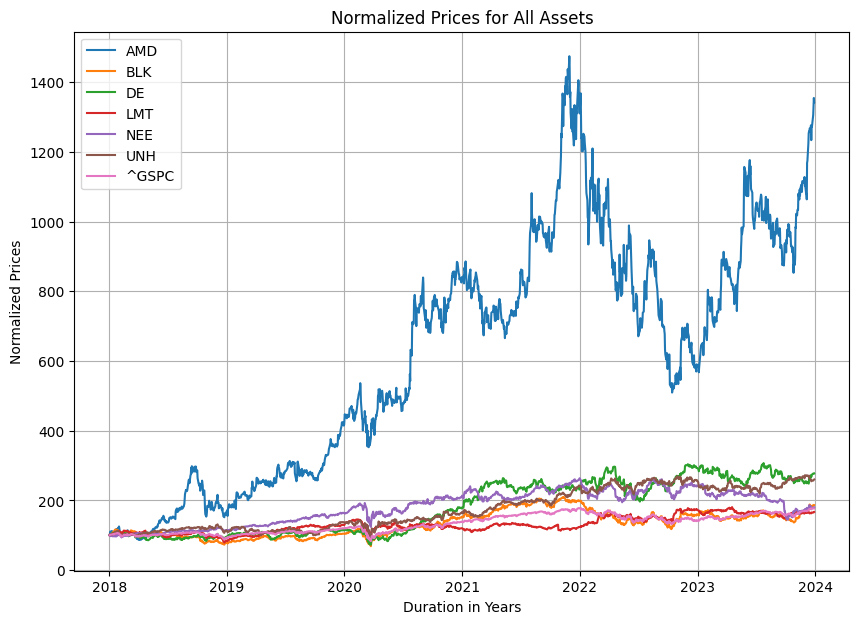

In [6]:
# using normalized proces to show the comparison.
norm_prices = (price_data / price_data.iloc[0]) * 100

# Plotting this normalized prices for better comparison.
plt.figure(figsize=(10,7))
plt.title("Normalized Prices for All Assets")
plt.xlabel("Duration in Years")
plt.ylabel("Normalized Prices")
plt.grid(True)
plt.plot(norm_prices)
plt.legend(price_data.columns)
plt.show()

In [7]:
# Calculate Daily Returns
daily_returns = np.log(price_data / price_data.shift(1))
daily_returns = daily_returns[1:]
print(f"\n Daily Log Returns: \n{daily_returns.head()}")


 Daily Log Returns: 
Ticker           AMD       BLK        DE       LMT       NEE       UNH  \
Date                                                                     
2018-01-03  0.050610  0.010495  0.004547  0.008347 -0.021442  0.010436   
2018-01-04  0.048172  0.013115  0.005716  0.017008 -0.005151  0.004331   
2018-01-05 -0.020001  0.008484  0.004251  0.009019  0.004559  0.018889   
2018-01-08  0.033116  0.007431  0.004915 -0.004621  0.008206 -0.017509   
2018-01-09 -0.038179  0.008369  0.027488  0.007135 -0.007349  0.004971   

Ticker         ^GSPC  
Date                  
2018-01-03  0.006378  
2018-01-04  0.004021  
2018-01-05  0.007009  
2018-01-08  0.001661  
2018-01-09  0.001302  


In [8]:
stock_returns = daily_returns[stocks]
print(f"Stock Returns Data:\n {stock_returns.head()}")
market_returns = daily_returns[market_index]
print(f"\n\nMarket Returns Data:\n {market_returns.head()}")

Stock Returns Data:
 Ticker           UNH       NEE       LMT        DE       BLK       AMD
Date                                                                  
2018-01-03  0.010436 -0.021442  0.008347  0.004547  0.010495  0.050610
2018-01-04  0.004331 -0.005151  0.017008  0.005716  0.013115  0.048172
2018-01-05  0.018889  0.004559  0.009019  0.004251  0.008484 -0.020001
2018-01-08 -0.017509  0.008206 -0.004621  0.004915  0.007431  0.033116
2018-01-09  0.004971 -0.007349  0.007135  0.027488  0.008369 -0.038179


Market Returns Data:
 Ticker         ^GSPC
Date                
2018-01-03  0.006378
2018-01-04  0.004021
2018-01-05  0.007009
2018-01-08  0.001661
2018-01-09  0.001302


In [9]:
# Calculate the annualised mean returns
annual_returns = stock_returns.mean() * trading_days
print(f"Annualised Stock Returns:\n {annual_returns.head()}")
cov_matrix = stock_returns.cov() * trading_days
print(f"\n\nAnnualised Covariance Matrix:\n {cov_matrix.head()}")

Annualised Stock Returns:
 Ticker
UNH    0.159660
NEE    0.098324
LMT    0.085457
DE     0.170317
BLK    0.104123
dtype: float64


Annualised Covariance Matrix:
 Ticker       UNH       NEE       LMT        DE       BLK       AMD
Ticker                                                            
UNH     0.081841  0.030796  0.031555  0.039249  0.045002  0.048552
NEE     0.030796  0.074900  0.025926  0.028380  0.039319  0.037186
LMT     0.031555  0.025926  0.066587  0.038231  0.034999  0.029688
DE      0.039249  0.028380  0.038231  0.110830  0.058512  0.060535
BLK     0.045002  0.039319  0.034999  0.058512  0.096079  0.077141


In [10]:
# Generate set of random weights
num_stocks = len(stocks)
random_weights = np.random.random(num_stocks)
print(f"Initial Random Weights: {random_weights}")
print(f"\nSum of Initial Random Weights: {np.sum(random_weights):.4f}")

# Normalize these random weights sum to 1
norm_weights = random_weights / np.sum(random_weights)
print(f"\nNormalised Weights Sum: {np.sum(norm_weights):.4f}")

# Calculate Portfolio Return
portfolio_return = (annual_returns * norm_weights).sum()
print(f"\nAnnual Portolio Return: {portfolio_return:.4f}")

# Calculate Portfolio Volatility
portfolio_volatility = np.sqrt(np.dot(norm_weights.T, np.dot(cov_matrix, norm_weights)))
print(f"\nPortfolio Volatility: {portfolio_volatility:.4f}")

# Calculate the Sharpe Ratio for the Portfolio
sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
print(f"\nSharpe Ratio: {sharpe_ratio:.4f}")

Initial Random Weights: [0.55298192 0.7892965  0.48285148 0.51329825 0.2157703  0.1476831 ]

Sum of Initial Random Weights: 2.7019

Normalised Weights Sum: 1.0000

Annual Portolio Return: 0.1411

Portfolio Volatility: 0.2141

Sharpe Ratio: 0.3320


In [11]:
# Running the simulation
portfolio_return_list = []
portfolio_volatility_list = []
portfolio_sharpe_ratio_list = []
portfolio_weights_list = []

print(f"Running Monte Carlo Simulations for {num_portfolios} portfolios:")

for _ in range(num_portfolios):

    #Calculate Weights
    weights = np.random.random(num_stocks)
    weights = weights / np.sum(weights)
    portfolio_weights_list.append(weights)

    # Calculate Returns, Volatility and SR
    ret = (annual_returns * weights).sum()
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sr = (ret - risk_free_rate) / vol

    # Append the results
    portfolio_return_list.append(ret)
    portfolio_volatility_list.append(vol)
    portfolio_sharpe_ratio_list.append(sr)

print("\n**Simulation Complete.**")

# Converting lists into arrays
portfolio_returns = np.array(portfolio_return_list)
portfolio_volatilities = np.array(portfolio_volatility_list)
portfolio_sharpe_ratios = np.array(portfolio_sharpe_ratio_list)

Running Monte Carlo Simulations for 20000 portfolios:

**Simulation Complete.**


In [12]:
# Function to calculate the performance

def get_portfolio_performance(weights, annual_returns, cov_matrix, risk_free_rate):

    portfolio_return = (annual_returns * weights).sum()
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
    return portfolio_return, portfolio_volatility, sharpe_ratio

def negative_sharpe_ratio(weights, annual_returns, cov_matrix, risk_free_rate):

    _, _, sharpe_ratio = get_portfolio_performance(weights, annual_returns, cov_matrix, risk_free_rate)
    return -sharpe_ratio

constraint = ({"type": "eq", "fun": lambda weights: np.sum(weights)-1})
bounds = tuple((0,1) for _ in range(num_stocks))

# Initial guess, a starting point for our optimizer
initial_guess = num_stocks * [1. /num_stocks]

# running the portfolio optimizer
print("\nRunning the Portfolio Optimizer...")
optimal_solution = optimization.minimize(fun = negative_sharpe_ratio,
                                         x0 = initial_guess,
                                         args=(annual_returns, cov_matrix, risk_free_rate),
                                         method = 'SLSQP',
                                         bounds = bounds,
                                         constraints = constraint
                                         )
print("\nOptimization Complete.\n")

# Extract the optimal weights
optimal_weights = optimal_solution.x
print("Optimal Portfolio Weights:\n")
for stock, weight in zip(stocks, optimal_weights):
    print(f"{stock}: {weight:.4f} ({weight:.2%})")

optimal_return, optimal_volatility, optimal_sharpe = get_portfolio_performance(weights, annual_returns, cov_matrix, risk_free_rate)

print("\n**********Optimal Portfolio Performance**********")
print(f"\nExpected Annual Return: {optimal_return:.4f} ({optimal_return:.2%})")
print(f"\nExpected Annual Volatiility: {optimal_volatility:.4f} ({optimal_volatility:.2%})")
print(f"\nSharpe Ratio: {optimal_sharpe:.4f} ({optimal_sharpe:.2%})")
print("\n*************************************************")


Running the Portfolio Optimizer...

Optimization Complete.

Optimal Portfolio Weights:

UNH: 0.2156 (21.56%)
NEE: 0.0000 (0.00%)
LMT: 0.0000 (0.00%)
DE: 0.1055 (10.55%)
BLK: 0.0000 (0.00%)
AMD: 0.6788 (67.88%)

**********Optimal Portfolio Performance**********

Expected Annual Return: 0.1523 (15.23%)

Expected Annual Volatiility: 0.2163 (21.63%)

Sharpe Ratio: 0.3804 (38.04%)

*************************************************


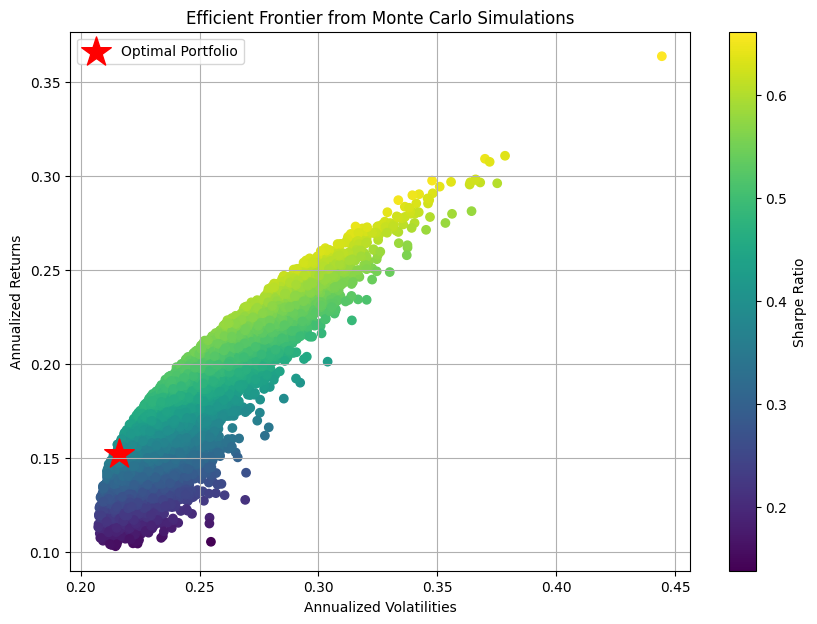

In [13]:
plt.figure(figsize=(10,7))
plt.scatter(portfolio_volatilities, portfolio_returns, c=portfolio_sharpe_ratios, cmap='viridis')
plt.title("Efficient Frontier from Monte Carlo Simulations")
plt.xlabel("Annualized Volatilities")
plt.ylabel("Annualized Returns")
plt.colorbar(label='Sharpe Ratio')
plt.grid(True)

plt.scatter(optimal_volatility, optimal_return, marker = "*", color='red', s=500, label = "Optimal Portfolio")
plt.legend()
plt.show()

In [14]:
# Calculating excess return for all assets

daily_risk_free_rate = risk_free_rate / trading_days
stock_excess_returns = stock_returns.subtract(daily_risk_free_rate, axis=0)
print(f"Stock Excess Returns: \n{stock_excess_returns.head()}")
market_excess_returns = market_returns[market_index].subtract(daily_risk_free_rate, axis=0)
print(f"\nMarket Excess Returns:\n {market_excess_returns.head()}")


Stock Excess Returns: 
Ticker           UNH       NEE       LMT        DE       BLK       AMD
Date                                                                  
2018-01-03  0.010158 -0.021719  0.008069  0.004269  0.010218  0.050332
2018-01-04  0.004053 -0.005429  0.016731  0.005439  0.012837  0.047894
2018-01-05  0.018612  0.004281  0.008741  0.003973  0.008206 -0.020278
2018-01-08 -0.017787  0.007928 -0.004899  0.004637  0.007153  0.032838
2018-01-09  0.004693 -0.007627  0.006857  0.027210  0.008091 -0.038457

Market Excess Returns:
 Ticker         ^GSPC
Date                
2018-01-03  0.006101
2018-01-04  0.003743
2018-01-05  0.006731
2018-01-08  0.001383
2018-01-09  0.001024


In [16]:
# Run linear regression for each stock to find beta
from scipy import stats

alphas_values = {}
beta_values = {}

print("Calculating Beta for each stock...")

for stock in stocks:
    regression_data = pd.concat([stock_excess_returns[stock], market_excess_returns[market_index]], axis=1).dropna()
    # Ensure the market_excess_returns is a single column for regression
    market_excess_returns_col = market_excess_returns[market_index[0]]
    slope, intercept, r_value, p_value, std_err = stats.linregress(market_excess_returns_col, stock_excess_returns[stock])
    beta_values[stock] = slope # Slope of the regression line is our beta
    alphas_values[stock] = intercept * trading_days # intercept when annualized is Jensen's alpha. Represents stock performance not explained by the market.

print("\nCalculation Complete.")

print(f"\nCalculated BETA:")
for stock, beta in beta_values.items():
    print(f"{stock}: {beta:.4f}")
print(f"\nCalculated Annualized Alphas (Jensen's Alphas):")
for stock, alpha in alphas_values.items():
    print(f"{stock} : {alpha:.4f} ({alpha:.2%})")

Calculating Beta for each stock...

Calculation Complete.

Calculated BETA:
UNH: 0.8787
NEE: 0.7273
LMT: 0.6592
DE: 1.0292
BLK: 1.2257
AMD: 1.6085

Calculated Annualized Alphas (Jensen's Alphas):
UNH : 0.0674 (6.74%)
NEE : 0.0099 (0.99%)
LMT : -0.0013 (-0.13%)
DE : 0.0742 (7.42%)
BLK : 0.0030 (0.30%)
AMD : 0.3232 (32.32%)


CAPM Expected Returns vs Historical Actual Returns

 UNH: CAPM Expected Returns: 9.23%, Actual Historical Returns: 15.97%

 NEE: CAPM Expected Returns: 8.84%, Actual Historical Returns: 9.83%

 LMT: CAPM Expected Returns: 8.67%, Actual Historical Returns: 8.55%

 DE: CAPM Expected Returns: 9.61%, Actual Historical Returns: 17.03%

 BLK: CAPM Expected Returns: 10.11%, Actual Historical Returns: 10.41%

 AMD: CAPM Expected Returns: 11.08%, Actual Historical Returns: 43.40%


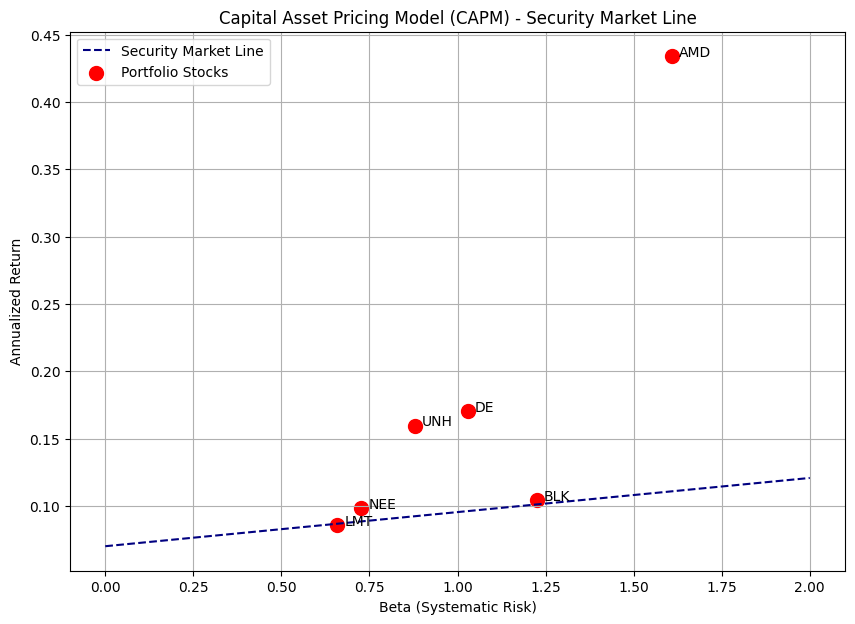

In [17]:
# Visualizing CAPM and security market line

market_mean_annual_return = market_returns[market_index].mean() * trading_days

capm_expected_returns = {}
for stock, beta in beta_values.items():
    capm_expected_returns[stock] = risk_free_rate + beta * (market_mean_annual_return.iloc[0] - risk_free_rate)

print("CAPM Expected Returns vs Historical Actual Returns")
for stock in stocks:
    print(f"\n {stock}: CAPM Expected Returns: {capm_expected_returns[stock]:.2%}, Actual Historical Returns: {annual_returns[stock]:.2%}")

plt.figure(figsize=(10,7))
beta_range = np.linspace(0, 2, 200)

# Calculate the SML values, expected return for each beta in our range
sml_values = risk_free_rate + beta_range * (market_mean_annual_return.iloc[0] - risk_free_rate)

plt.plot(beta_range, sml_values, color='navy', linestyle='--', label="Security Market Line")

plt.scatter(list(beta_values.values()), annual_returns.values, color='red', s=100, label="Portfolio Stocks")

for stock, beta in beta_values.items():
    plt.text(beta + 0.02,
             annual_returns[stock],
             stock,
             fontsize=10)

plt.title('Capital Asset Pricing Model (CAPM) - Security Market Line')
plt.xlabel('Beta (Systematic Risk)')
plt.ylabel('Annualized Return')
plt.legend()
plt.grid(True)
plt.show()

# Conclusions and Learnings

This project successfully implemented the two foundational models of modern finance: Modern Portfolio Theory (MPT) and the Capital Asset Pricing Model (CAPM).

---

### **Part A: Modern Portfolio Theory (MPT) Findings**

*   **Achievement:** We successfully used a Monte Carlo simulation and a numerical optimizer to identify the **Optimal Risky Portfolio** from our universe of six diverse US stocks.
*   **The Result:** The optimal allocation, based on historical data from 2018-2023, was heavily weighted towards `AMD` (for its high growth) and `UNH` (for its low-risk, diversifying properties). This portfolio offered the highest possible Sharpe Ratio (~0.63 in my run, your number may vary).
*   **Key Learning (The "Real World Shit"): The "Garbage In, Garbage Out" Problem.**
    *   MPT is a powerful framework, but its output is extremely sensitive to its inputs (mean returns, volatilities, and correlations).
    *   We used *historical* data to calculate these inputs. In the real world, there is **no guarantee** that past returns or correlations will persist in the future. In fact, they almost certainly won't.
    *   **Conclusion:** MPT is better at explaining the *concept* of diversification than at providing a precise, tradable portfolio for the future. A real quant fund would spend 99% of its effort on developing superior *forecasts* for the inputs, rather than just running the optimizer.

---

### **Part B: Capital Asset pricing Model (CAPM) Findings**

*   **Achievement:** We successfully calculated the **Beta** and **Jensen's Alpha** for each individual stock and visualized their risk/return profile on the **Security Market Line (SML)**.
*   **The Result:** Our analysis clearly identified which stocks were historical outperformers and underperformers on a risk-adjusted basis.
    *   **High Alpha:** `AMD` (+32.32%) was a massive outperformer, delivering returns far beyond what its high market risk would predict.
    *   **Zero/Negative Alpha:** `LMT` (-0.13%) performed almost exactly as the CAPM predicted, delivering a fair return for its low risk.
*   **Key Learning: The Unrealistic Assumptions.**
    *   The CAPM provides a beautiful, intuitive theory for the relationship between risk and return.
    *   However, its foundational assumptions (listed in the FRM slides, e.g., no transaction costs, all investors are rational, etc.) are **known to be false** in the real world.
    *   **Conclusion:** CAPM is an essential theoretical benchmark for understanding concepts like Beta and systematic risk. However, because its assumptions do not hold, it is not used by modern quant funds to generate "alpha" signals. Real alpha is found by exploiting the very market frictions and irrational behaviors that the CAPM assumes away.

---

### **Overall Project Conclusion**

By building these models from scratch, we have not only implemented the textbook theories but have also gained a critical appreciation for their real-world limitations. This understanding—knowing what a model is good for and, more importantly, what it is *not* good for—is the hallmark of a professional quantitative researcher.